In [ ]:
!pip install qiskit qiskit-aer

In [ ]:
from qiskit import *

qc = QuantumCircuit(3, 3)

qc.draw()

q_0: 
     
q_1: 
     
q_2: 
     
c: 3/

In [ ]:
qc.x(0)  # used to apply an X gate.


qc.barrier()
qc.draw()

┌───┐ ░ 
q_0: ┤ X ├─░─
     └───┘ ░ 
q_1: ──────░─
           ░ 
q_2: ──────░─
           ░ 
c: 3/════════

In [ ]:
# This is how we apply a Hadamard gate on Q1.
qc.h(1)

# This is the CX gate, which takes two parameters, Control qubit and the target qubit
qc.cx(1, 2)
qc.draw()

┌───┐ ░           
q_0: ┤ X ├─░───────────
     └───┘ ░ ┌───┐     
q_1: ──────░─┤ H ├──■──
           ░ └───┘┌─┴─┐
q_2: ──────░──────┤ X ├
           ░      └───┘
c: 3/══════════════════

In [ ]:
# The next step is to create a controlled gate between qubit 0 and qubit 1.
# and applying a Hadamard gate to q0.
qc.cx(0, 1)
qc.h(0)

qc.barrier()

# the next step is to do the two measurements
# on q0 and q1.
qc.measure([0, 1], [0, 1])

qc.draw()

┌───┐ ░                ┌───┐ ░ ┌─┐   
q_0: ┤ X ├─░─────────────■──┤ H ├─░─┤M├───
     └───┘ ░ ┌───┐     ┌─┴─┐└───┘ ░ └╥┘┌─┐
q_1: ──────░─┤ H ├──■──┤ X ├──────░──╫─┤M├
           ░ └───┘┌─┴─┐└───┘      ░  ║ └╥┘
q_2: ──────░──────┤ X ├───────────░──╫──╫─
           ░      └───┘           ░  ║  ║ 
c: 3/════════════════════════════════╩══╩═
                                     0  1

In [ ]:
qc.barrier()
qc.cx(1, 2)
qc.cz(0, 2)
qc.draw()

┌───┐ ░                ┌───┐ ░ ┌─┐    ░         
q_0: ┤ X ├─░─────────────■──┤ H ├─░─┤M├────░───────■─
     └───┘ ░ ┌───┐     ┌─┴─┐└───┘ ░ └╥┘┌─┐ ░       │ 
q_1: ──────░─┤ H ├──■──┤ X ├──────░──╫─┤M├─░───■───┼─
           ░ └───┘┌─┴─┐└───┘      ░  ║ └╥┘ ░ ┌─┴─┐ │ 
q_2: ──────░──────┤ X ├───────────░──╫──╫──░─┤ X ├─■─
           ░      └───┘           ░  ║  ║  ░ └───┘   
c: 3/════════════════════════════════╩══╩════════════
                                     0  1

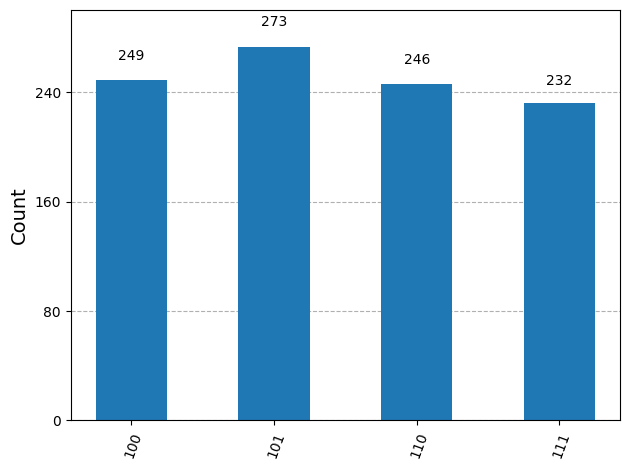

In [ ]:
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit import transpile

sim = AerSimulator()

qc.measure(2, 2)

compiled_circuit = transpile(qc, sim)

result = sim.run(compiled_circuit, shots=1000).result()
counts = result.get_counts()

plot_histogram(counts)